# Score-Based Models, SDEs, and Probability Flow ODEs

When the number of diffusion steps becomes large and each corruption step becomes very small, the discrete noising chain is naturally rewritten in continuous time. The forward process is then described by a **stochastic differential equation**, and generation becomes the numerical solution of a reverse-time denoising dynamics. This formulation makes the geometry of diffusion models more explicit: the network is not only predicting noise, but also describing how probability mass should flow back toward the data distribution at every noise level.

At the center of the discussion is the **score field** $\nabla_{\boldsymbol{x}} \log p_t(\boldsymbol{x})$. In the discrete DDPM construction, the model is trained to predict the Gaussian perturbation added at time $t$. In the continuous picture, the same prediction can be converted into a score, and that score can drive either a stochastic reverse-time SDE or a deterministic probability-flow ODE. The resulting theory explains why a single trained denoiser can support several different samplers while still being tied to the same family of marginals.

The continuous-time score-based formulation used here follows Song et al. {cite}`song2021scorebased`, while the denoising-score-matching bridge goes back to Song and Ermon {cite}`song2020denoising`.


A pretrained FashionMNIST DDPM denoiser can therefore be reused almost verbatim. The main extra ingredients are the score conversion formula, the interpretation of the discrete schedule as a continuous variance-preserving path, and the choice of numerical solver. Once these ingredients are in place, ancestral DDPM sampling, reverse-SDE sampling, and probability-flow ODE sampling appear as different discretizations of one underlying denoising geometry.


```{important}
A pretrained **noise predictor** already contains a **score model**. Continuous-time diffusion is the language that makes this statement precise.
```

## ODEs, Trajectories, and Deterministic Dynamics

An **ordinary differential equation** such as
:::{math}
\frac{d\boldsymbol{x}}{dt} = \boldsymbol{f}(\boldsymbol{x}(t), t)
:::
assigns a velocity vector to every point of space and every time instant. Once an initial condition is fixed, the equation determines an entire **trajectory** $t \mapsto \boldsymbol{x}(t)$. The sample does not jump arbitrarily from one location to another. It moves by following the vector field prescribed by $\boldsymbol{f}$. This is the most basic continuous-time picture of generation: start from some initial state and let a learned dynamics transport it through space.

The geometric viewpoint matters because it turns generation into a problem of designing trajectories. If the vector field points in sensible directions, the path remains coherent and gradually approaches the region of interest. If the vector field is poor, the trajectory drifts into implausible configurations. In this sense, an ODE already contains the seed of a generative model: the model is not only a density or a sampler, but also a rule saying how samples should move over time.


```{admonition} Numerical Example: A One-Dimensional Score
:class: numerical-example
Suppose that at some noise level the marginal density were a Gaussian centered at $2$ with unit variance. Then
:::{math}
\nabla_x \log p_t(x) = -(x-2).
:::
If the current sample is $x=5$, the score is $-3$, so the vector field points left, toward the high-density region. If the current sample is $x=0$, the score is $2$, so the vector field points right. The score does not report the density value itself. It reports the **local direction in which the sample should move to become more probable**.
```

## From ODEs to SDEs

A pure ODE is often too rigid for a corruption process. If the goal is to spread the data distribution until it becomes close to a simple Gaussian reference, deterministic motion alone is usually not enough. This is why diffusion models move from ODEs to **stochastic differential equations**:
:::{math}
d\boldsymbol{x} = \boldsymbol{f}(\boldsymbol{x}, t)\,dt + g(t)\,d\boldsymbol{w},
:::
where $\boldsymbol{w}$ is Brownian motion. The drift $\boldsymbol{f}$ provides systematic motion, while the diffusion coefficient $g(t)$ injects randomness continuously over time.

The interpretation changes in an important way. A trajectory is no longer fixed by its initial condition alone. Once stochasticity is added, the model defines a **distribution over trajectories**. This is exactly the right language for a noising process: two samples starting from the same clean image can follow different corrupted paths, while still sharing the same one-time marginals.


## The Diffusion SDE: the Variance-Preserving Process

The main continuous-time family connected with DDPMs is the **variance-preserving SDE**
:::{math}
d\boldsymbol{x}
=
-\frac{1}{2}\beta(t)\boldsymbol{x}\,dt + \sqrt{\beta(t)}\,d\boldsymbol{w}.
:::
Its drift gradually damps the signal, while its diffusion term injects Gaussian noise. If one defines the continuous cumulative retention factor
:::{math}
\bar{\alpha}(t)
=
\exp\left(-\int_0^t \beta(s)\,ds\right),
:::
then the forward marginal is
:::{math}
\boldsymbol{x}_t
=
\sqrt{\bar{\alpha}(t)}\,\boldsymbol{x}_0 + \sqrt{1-\bar{\alpha}(t)}\,\boldsymbol{\varepsilon},
\qquad
\boldsymbol{\varepsilon}\sim\mathcal{N}(\boldsymbol{0},\boldsymbol{I}).
:::
This is the continuous counterpart of the forward noising chain from the discrete chapter. The key difference is only that time is now smooth. The probability path is no longer described by finitely many coefficients, but by the function $\beta(t)$ and the induced retention factor $\bar{\alpha}(t)$ {cite}`song2021scorebased,ho2020denoising`.


```{prf:theorem} VP-SDE forward marginal
:label: thm-vp-marginal-fashion
For the variance-preserving SDE,
:::{math}
d\boldsymbol{x}
=
-\frac{1}{2}\beta(t)\boldsymbol{x}\,dt + \sqrt{\beta(t)}\,d\boldsymbol{w},
:::
the conditional law of $\boldsymbol{x}_t$ given $\boldsymbol{x}_0$ is Gaussian with
:::{math}
p(\boldsymbol{x}_t|\boldsymbol{x}_0)
=
\mathcal{N}\left(
\sqrt{\bar{\alpha}(t)}\,\boldsymbol{x}_0,
(1-\bar{\alpha}(t))\boldsymbol{I}
\right).
:::
```

## The Reverse SDE and the Emergence of the Score

The forward VP-SDE tells how data are progressively corrupted. Generation requires the opposite direction: start from a simple noisy distribution and move backward toward the data. For a generic forward diffusion
:::{math}
d\boldsymbol{x} = \boldsymbol{f}(\boldsymbol{x},t)\,dt + g(t)\,d\boldsymbol{w},
:::
the reverse-time SDE has drift
:::{math}
\boldsymbol{f}(\boldsymbol{x},t) - g(t)^2\nabla_{\boldsymbol{x}}\log p_t(\boldsymbol{x}).
:::
This is the first place where the **score** enters naturally. The reverse dynamics do not only undo the forward drift. They also need the gradient of the log-density of the current noisy marginal, because that gradient tells the sample in which local direction probability mass increases.

For the VP family this becomes
:::{math}
d\boldsymbol{x}
=
\left[
-\frac{1}{2}\beta(t)\boldsymbol{x} - \beta(t)\nabla_{\boldsymbol{x}}\log p_t(\boldsymbol{x})
\right]dt + \sqrt{\beta(t)}\,d\bar{\boldsymbol{w}}.
:::
If the score were known exactly, simulating this reverse SDE would already yield a generative algorithm.


## Approximating the Score with a Neural Network

The reverse VP-SDE is conceptually elegant, but it is not directly usable because the score
:::{math}
\nabla_{\boldsymbol{x}}\log p_t(\boldsymbol{x})
:::
is unknown. This is the central learning problem in score-based modeling: replace the exact score by a neural approximation
:::{math}
\boldsymbol{s}_\theta(\boldsymbol{x}, t) \approx \nabla_{\boldsymbol{x}}\log p_t(\boldsymbol{x}).
:::
Once such an approximation is available, the reverse SDE becomes a sampler. The remaining questions are then how to train $\boldsymbol{s}_\theta$, how it relates to the DDPM noise predictor, and how different numerical discretizations of the reverse dynamics lead to algorithms such as DDPM and DDIM.


## Denoising Score Matching

Suppose now that the score field is unknown, as it always is in practice. The key simplification is to corrupt data with a noise process whose conditional score is known analytically, and then train a neural network against that explicit target. In other words, the intractable score of the noisy-data density is replaced by a supervised regression problem induced by Gaussian perturbations.

Consider Gaussian perturbations
:::{math}
\widetilde{\boldsymbol{x}} = \boldsymbol{x} + \sigma \boldsymbol{\varepsilon},
\qquad
\boldsymbol{\varepsilon} \sim \mathcal{N}(\boldsymbol{0},\boldsymbol{I}),
:::
with $\boldsymbol{x} \sim p_{gt}$. Let $p_\sigma$ be the density of the perturbed variable $\widetilde{\boldsymbol{x}}$. A network can be trained to estimate the score of that noisy density by minimizing a regression loss against the known Gaussian conditional score
:::{math}
\nabla_{\widetilde{\boldsymbol{x}}}\log q_\sigma(\widetilde{\boldsymbol{x}}|\boldsymbol{x})
=
-\frac{\widetilde{\boldsymbol{x}}-\boldsymbol{x}}{\sigma^2}.
:::
This is the denoising-score-matching viewpoint introduced in {cite}`song2020denoising`.


```{prf:theorem} Denoising score matching recovers the noisy-data score
:label: thm-dsm-fashion
The minimizer of
:::{math}
\mathcal{L}(\theta)
=
\mathbb{E}\left[
\left\|
\boldsymbol{s}_\theta(\widetilde{\boldsymbol{x}},\sigma)
+
\frac{\widetilde{\boldsymbol{x}}-\boldsymbol{x}}{\sigma^2}
\right\|_2^2
\right]
:::
is the score of the perturbed density:
:::{math}
\boldsymbol{s}_\theta^*(\widetilde{\boldsymbol{x}},\sigma)
=
\nabla_{\widetilde{\boldsymbol{x}}}\log p_\sigma(\widetilde{\boldsymbol{x}}).
:::
```

```{prf:proof}
Condition on $\widetilde{\boldsymbol{x}}$. The optimal regression target is the conditional expectation of the known Gaussian target:
:::{math}
\boldsymbol{s}_\theta^*(\widetilde{\boldsymbol{x}},\sigma)
=
\mathbb{E}\left[
-\frac{\widetilde{\boldsymbol{x}}-\boldsymbol{x}}{\sigma^2}
\middle|
\widetilde{\boldsymbol{x}}
\right].
:::
The denoising-score-matching identity shows that this conditional expectation is exactly the score of the perturbed density,
:::{math}
\nabla_{\widetilde{\boldsymbol{x}}}\log p_\sigma(\widetilde{\boldsymbol{x}}).
:::
The network is therefore optimized against a target induced by the known corruption law, but the optimum is the score of the unknown noisy-data distribution.
```

This is the continuous-time analogue of what happened in DDPM training. The generative problem is not attacked by estimating a high-dimensional density directly. It is attacked by constructing a corruption mechanism that manufactures a supervised target. Once the perturbation process is explicit, score estimation becomes a denoising regression problem.


## Sampling as a Discretization of the Reverse VP-SDE

If a score approximation $\boldsymbol{s}_\theta$ is available, the reverse VP-SDE can be simulated numerically. Over a small backward interval of length $\Delta t$, an Euler-Maruyama step takes the form
:::{math}
\boldsymbol{x}_{t-\Delta t}
\approx
\boldsymbol{x}_t
+
\left[
\frac{1}{2}\beta(t)\boldsymbol{x}_t + \beta(t)\boldsymbol{s}_\theta(\boldsymbol{x}_t,t)
\right]\Delta t
+
\sqrt{\beta(t)\Delta t}\,\boldsymbol{z},
\qquad
\boldsymbol{z}\sim\mathcal{N}(\boldsymbol{0},\boldsymbol{I}).
:::
This is the continuous-time ancestor of diffusion sampling. The model repeatedly estimates how the current noisy sample should move toward higher probability and then injects the stochastic correction required by the reverse diffusion law. In discrete diffusion language, this is the logic behind **ancestral sampling**.


## Using a Pretrained Noise Predictor to Approximate the Score

The abstract score-network discussion becomes concrete once one reuses the denoiser from the discrete DDPM model. Suppose the network has been trained in the usual noise-prediction form, so that
:::{math}
\boldsymbol{\varepsilon}_\theta(\boldsymbol{x}_t,t) \approx \boldsymbol{\varepsilon}.
:::
For the VP perturbation path, the Gaussian conditional score is known in closed form. This makes it possible to convert the noise predictor into a score predictor with an explicit formula. It also yields a reconstruction formula for the clean image hidden inside $\boldsymbol{x}_t$, which is the diffusion-model incarnation of **Tweedie's formula**: once the score of the noisy marginal is known, one can estimate the underlying clean signal.


```{prf:theorem} Score, clean-image reconstruction, and a pretrained noise predictor
:label: thm-score-from-noise-fashion
For the variance-preserving forward marginal,
:::{math}
\boldsymbol{s}_\theta(\boldsymbol{x}_t,t)
=
-\frac{\boldsymbol{\varepsilon}_\theta(\boldsymbol{x}_t,t)}{\sqrt{1-\bar{\alpha}(t)}}.
:::
In the discrete DDPM notation this becomes
:::{math}
\boldsymbol{s}_\theta(\boldsymbol{x}_t,t)
=
-\frac{\boldsymbol{\varepsilon}_\theta(\boldsymbol{x}_t,t)}{\sqrt{1-\alpha_t}}.
:::
Equivalently, the clean-image estimate can be written as
:::{math}
\hat{\boldsymbol{x}}_{0|t}
=
\frac{\boldsymbol{x}_t + (1-\alpha_t)\boldsymbol{s}_\theta(\boldsymbol{x}_t,t)}{\sqrt{\alpha_t}}
=
\frac{\boldsymbol{x}_t - \sqrt{1-\alpha_t}\,\boldsymbol{\varepsilon}_\theta(\boldsymbol{x}_t,t)}{\sqrt{\alpha_t}}.
:::
This is the diffusion-style form of Tweedie's formula.
```


```{prf:proof}
The Gaussian forward conditional satisfies
:::{math}
\nabla_{\boldsymbol{x}_t}\log p(\boldsymbol{x}_t|\boldsymbol{x}_0)
=
-\frac{\boldsymbol{x}_t-\sqrt{\bar{\alpha}(t)}\,\boldsymbol{x}_0}{1-\bar{\alpha}(t)}.
:::
Using
:::{math}
\boldsymbol{x}_t-\sqrt{\bar{\alpha}(t)}\,\boldsymbol{x}_0
=
\sqrt{1-\bar{\alpha}(t)}\,\boldsymbol{\varepsilon},
:::
one gets
:::{math}
\nabla_{\boldsymbol{x}_t}\log p(\boldsymbol{x}_t|\boldsymbol{x}_0)
=
-\frac{\boldsymbol{\varepsilon}}{\sqrt{1-\bar{\alpha}(t)}}.
:::
Replacing the unknown noise by the neural estimate gives the score formula.

Now solve the forward marginal identity
:::{math}
\boldsymbol{x}_t = \sqrt{\alpha_t}\,\boldsymbol{x}_0 + \sqrt{1-\alpha_t}\,\boldsymbol{\varepsilon}
:::
for $\boldsymbol{x}_0$ and substitute either the predicted noise or the score formula. This gives
:::{math}
\hat{\boldsymbol{x}}_{0|t}
=
\frac{\boldsymbol{x}_t - \sqrt{1-\alpha_t}\,\boldsymbol{\varepsilon}_\theta(\boldsymbol{x}_t,t)}{\sqrt{\alpha_t}}
=
\frac{\boldsymbol{x}_t + (1-\alpha_t)\boldsymbol{s}_\theta(\boldsymbol{x}_t,t)}{\sqrt{\alpha_t}}.
:::
The second expression is the Tweedie-style reconstruction formula written in diffusion notation.
```


This identity is the exact bridge from the previous notebook to the current one. Once a DDPM denoiser has been trained, the score field is already present implicitly inside the noise predictor. The same formula also explains why diffusion samplers repeatedly build $\hat{\boldsymbol{x}}_{0|t}$: they are using the score of the noisy marginal to infer the cleaner configuration hidden underneath the current sample.


```{prf:theorem} DDPM as a finite-step VP diffusion
:label: thm-ddpm-is-vp
Let $0 = t_0 < t_1 < \cdots < t_T = 1$ be a time grid with small increments $\Delta t_k = t_k - t_{k-1}$. Define the discrete variance increment
:::{math}
\beta_k^{disc} = \beta(t_{k-1})\Delta t_k,
\qquad
\bar{\alpha}_k = 1 - \beta_k^{disc},
\qquad
\alpha_k = \prod_{s=1}^k \bar{\alpha}_s.
:::
Then an Euler-Maruyama discretization of the forward VP-SDE produces, to first order in $\Delta t_k$,
:::{math}
\boldsymbol{x}_k
\approx
\sqrt{\bar{\alpha}_k}\,\boldsymbol{x}_{k-1} + \sqrt{1-\bar{\alpha}_k}\,\boldsymbol{\xi}_k,
\qquad
\boldsymbol{\xi}_k \sim \mathcal{N}(\boldsymbol{0},\boldsymbol{I}),
:::
which is exactly the DDPM forward transition. Iterating the transitions gives the DDPM marginal
:::{math}
\boldsymbol{x}_k
=
\sqrt{\alpha_k}\,\boldsymbol{x}_0 + \sqrt{1-\alpha_k}\,\boldsymbol{\varepsilon}.
:::
Moreover, the reverse-time VP diffusion over one small interval is Gaussian, and its first-order discretization yields the DDPM reverse sampler. In this sense, DDPM is the finite-step variance-preserving diffusion model associated with the VP-SDE.
```


```{prf:proof}
Over one short interval $[t_{k-1}, t_k]$, Euler-Maruyama gives
:::{math}
\boldsymbol{x}_k
=
\boldsymbol{x}_{k-1}
-
\frac{1}{2}\beta(t_{k-1})\boldsymbol{x}_{k-1}\Delta t_k
+
\sqrt{\beta(t_{k-1})\Delta t_k}\,\boldsymbol{\xi}_k.
:::
Because $\Delta t_k$ is small,
:::{math}
\sqrt{1-\beta_k^{disc}}
=
1 - \frac{1}{2}\beta_k^{disc} + O((\Delta t_k)^2).
:::
Substituting $\beta_k^{disc} = \beta(t_{k-1})\Delta t_k$ shows that the Euler-Maruyama update and
:::{math}
\boldsymbol{x}_k
=
\sqrt{\bar{\alpha}_k}\,\boldsymbol{x}_{k-1} + \sqrt{1-\bar{\alpha}_k}\,\boldsymbol{\xi}_k
:::
have the same mean and covariance up to first order. This is precisely the DDPM forward transition with per-step retention coefficient $\bar{\alpha}_k$.

Iterating the Gaussian transitions gives
:::{math}
\boldsymbol{x}_k
=
\sqrt{\prod_{s=1}^k \bar{\alpha}_s}\,\boldsymbol{x}_0
+
\sum_{j=1}^k
\left(
\sqrt{1-\bar{\alpha}_j}\prod_{s=j+1}^k \sqrt{\bar{\alpha}_s}
\right)\boldsymbol{\xi}_j.
:::
The sum is Gaussian, and its covariance is
:::{math}
\sum_{j=1}^k
\left(1-\bar{\alpha}_j\right)
\prod_{s=j+1}^k \bar{\alpha}_s
=
1 - \prod_{s=1}^k \bar{\alpha}_s
=
1-\alpha_k.
:::
Therefore
:::{math}
\boldsymbol{x}_k
=
\sqrt{\alpha_k}\,\boldsymbol{x}_0 + \sqrt{1-\alpha_k}\,\boldsymbol{\varepsilon},
\qquad
\boldsymbol{\varepsilon}\sim\mathcal{N}(\boldsymbol{0},\boldsymbol{I}),
:::
which is the DDPM forward marginal.

For the reverse process, the VP-SDE reverse dynamics over a sufficiently short interval are also Gaussian. Replacing the true score with its learned approximation and freezing the variance over that interval yields the familiar DDPM reverse kernel with mean determined by the network prediction and variance inherited from the schedule. The ancestral DDPM sampler is therefore the stepwise Gaussian discretization of the reverse-time VP diffusion.
```


## The Probability-Flow ODE Associated with the VP-SDE

The reverse SDE is not the only dynamics compatible with the same marginals. Song et al. showed that one can remove the stochastic term and obtain a deterministic **probability-flow ODE**:
:::{math}
\frac{d\boldsymbol{x}}{dt}
=
\boldsymbol{f}(\boldsymbol{x},t) - \frac{1}{2}g(t)^2\nabla_{\boldsymbol{x}}\log p_t(\boldsymbol{x}).
:::
For the VP family this becomes
:::{math}
\frac{d\boldsymbol{x}}{dt}
=
-\frac{1}{2}\beta(t)\boldsymbol{x} - \frac{1}{2}\beta(t)\nabla_{\boldsymbol{x}}\log p_t(\boldsymbol{x}).
:::
The one-time marginals of this ODE agree with those of the reverse-time SDE, but the trajectories are deterministic. This is the continuous-time object that sits behind deterministic diffusion samplers such as DDIM {cite}`song2021scorebased,song2020ddim`.


## First-Order Discretizations of the Probability-Flow ODE

Once the PF-ODE is available, sampling becomes a numerical-integration problem. The simplest option is a first-order scheme: over a short interval one freezes the vector field at the current point and advances with an Euler step. In backward time this means
:::{math}
\boldsymbol{x}_{t-\Delta t}
\approx
\boldsymbol{x}_t
+
\left[
\frac{1}{2}\beta(t)\boldsymbol{x}_t + \frac{1}{2}\beta(t)\boldsymbol{s}_\theta(\boldsymbol{x}_t,t)
\right]\Delta t.
:::
Unlike the reverse SDE discretization, there is no fresh Gaussian perturbation. The same initial terminal noise therefore always produces the same trajectory. This deterministic viewpoint is precisely what makes the connection with DDIM so clean.


```{prf:theorem} Probability-flow ODE discretizes to deterministic DDIM
:label: thm-ddim-pfode-fashion
Consider the VP family and assume the denoiser provides a noise estimate $\boldsymbol{\varepsilon}_\theta(\boldsymbol{x}_t,t)$ together with the implied clean-image estimate
:::{math}
\hat{\boldsymbol{x}}_{0|t}
=
\frac{\boldsymbol{x}_t - \sqrt{1-\alpha(t)}\,\boldsymbol{\varepsilon}_\theta(\boldsymbol{x}_t,t)}{\sqrt{\alpha(t)}}.
:::
If one advances from time $t$ to an earlier time $t' < t$ by the deterministic update
:::{math}
\boldsymbol{x}_{t'}
=
\sqrt{\alpha(t')}\,\hat{\boldsymbol{x}}_{0|t} + \sqrt{1-\alpha(t')}\,\boldsymbol{\varepsilon}_\theta(\boldsymbol{x}_t,t),
:::
then the resulting scheme is exactly DDIM with $\eta = 0$. Moreover, if the probability-flow ODE is integrated over the interval $[t',t]$ while freezing the denoiser output on that interval, the resulting integral update is exactly the deterministic DDIM step. Consequently, once $\boldsymbol{x}_T$ is fixed, the whole DDIM trajectory is fixed.
```


```{prf:proof}
The first statement is immediate: the displayed update is the deterministic DDIM rule, written with continuous-time notation $\alpha(t)$ instead of a discrete index. Because no fresh Gaussian perturbation is injected, every iterate is a deterministic function of the previous one. Fixing $\boldsymbol{x}_T$ therefore fixes the whole trajectory.

To connect this update to the probability-flow ODE, write on the interval $[t',t]$
:::{math}
\widetilde{\boldsymbol{x}}(\tau)
=
\sqrt{\alpha(\tau)}\,\hat{\boldsymbol{x}}_{0|t} + \sqrt{1-\alpha(\tau)}\,\boldsymbol{\varepsilon}_\theta(\boldsymbol{x}_t,t),
\qquad \tau \in [t',t],
:::
where the denoiser output is frozen at its value computed from $(\boldsymbol{x}_t,t)$. Since
:::{math}
\alpha'(\tau) = -\beta(\tau)\alpha(\tau),
:::
differentiating gives
:::{math}
\frac{d\widetilde{\boldsymbol{x}}}{d\tau}
=
-\frac{1}{2}\beta(\tau)\sqrt{\alpha(\tau)}\,\hat{\boldsymbol{x}}_{0|t}
+
\frac{\beta(\tau)\alpha(\tau)}{2\sqrt{1-\alpha(\tau)}}\,\boldsymbol{\varepsilon}_\theta.
:::
Now use the score conversion formula
:::{math}
\boldsymbol{s}_\theta(\widetilde{\boldsymbol{x}}(\tau),\tau)
=
-\frac{\boldsymbol{\varepsilon}_\theta}{\sqrt{1-\alpha(\tau)}}
:::
and the decomposition
:::{math}
\widetilde{\boldsymbol{x}}(\tau)
=
\sqrt{\alpha(\tau)}\,\hat{\boldsymbol{x}}_{0|t} + \sqrt{1-\alpha(\tau)}\,\boldsymbol{\varepsilon}_\theta.
:::
Substituting both identities yields
:::{math}
\frac{d\widetilde{\boldsymbol{x}}}{d\tau}
=
-\frac{1}{2}\beta(\tau)\widetilde{\boldsymbol{x}}(\tau) - \frac{1}{2}\beta(\tau)\boldsymbol{s}_\theta(\widetilde{\boldsymbol{x}}(\tau),\tau),
:::
which is exactly the VP probability-flow ODE with the learned score in place of the exact one.

Integrating this ODE from $t$ backward to $t'$ gives
:::{math}
\boldsymbol{x}_{t'}
=
\boldsymbol{x}_t - \int_t^{t'}
\left[
-\frac{1}{2}\beta(\tau)\widetilde{\boldsymbol{x}}(\tau) - \frac{1}{2}\beta(\tau)\boldsymbol{s}_\theta(\widetilde{\boldsymbol{x}}(\tau),\tau)
\right]d\tau.
:::
Because $\widetilde{\boldsymbol{x}}(\tau)$ was constructed so that its derivative is exactly the integrand, the fundamental theorem of calculus gives
:::{math}
\boldsymbol{x}_{t'}
=
\widetilde{\boldsymbol{x}}(t')
=
\sqrt{\alpha(t')}\,\hat{\boldsymbol{x}}_{0|t} + \sqrt{1-\alpha(t')}\,\boldsymbol{\varepsilon}_\theta(\boldsymbol{x}_t,t).
:::
This is precisely the deterministic DDIM update.

Equivalently, one may view the argument as a one-step discretization of the PF-ODE in which the denoiser output is held constant across the interval and the resulting integral is evaluated in closed form through the coefficients $\sqrt{\alpha(\tau)}$ and $\sqrt{1-\alpha(\tau)}$. Therefore deterministic DDIM is the natural finite-step integral solver associated with the VP probability-flow ODE.
```


The continuous formulation therefore organizes several samplers around a single learned field. The VP-SDE explains the forward corruption law. The reverse-time SDE gives a stochastic denoising sampler whose finite-step version is ancestral DDPM. The probability-flow ODE gives a deterministic denoising sampler whose finite-step version is DDIM with $\eta = 0$. What changes from one algorithm to another is the numerical path; the learned denoiser and the underlying probability family remain the same.


## Using the FashionMNIST DDPM Denoiser as a Score Network

The implementation below uses the same `FashionMNIST` denoiser trained in the DDPM notebook. The network architecture, time embedding, and discrete schedule are kept identical. After loading the weights, the score is obtained through the theorem above, and the resulting field is used to run three samplers on the same model:

- the **ancestral DDPM sampler**;
- an **Euler-Maruyama reverse-SDE sampler**;
- a **probability-flow ODE sampler**.

Because all three samplers are driven by the same denoiser, the comparison is about the geometry of the reverse dynamics rather than about differences in training.

This reuse of a pretrained DDPM denoiser is not a separate trick; it is exactly the relationship between noise prediction and score prediction highlighted by {cite}`song2021scorebased`.

### Loading the Pretrained DDPM Denoiser

In [9]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
from torchvision import datasets, transforms, utils
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(7)
if device.type == "cuda":
    torch.cuda.manual_seed_all(7)

project_root = Path.cwd() if (Path.cwd() / "_config.yml").exists() else Path.cwd().parent
artifacts_dir = project_root / "artifacts"
artifacts_dir.mkdir(exist_ok=True)
ddpm_checkpoint_path = artifacts_dir / "ddpm_fashionmnist.pt"

batch_size = 128
metric_batch_size = 64
num_workers = 0
image_size = 28
channels = 1
base_channels = 64
time_dim = 128
timesteps = 300

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: 2.0 * x - 1.0),
])

test_dataset = datasets.FashionMNIST(root=project_root / "data", train=False, download=True, transform=transform)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=(device.type == "cuda"),
)


In [10]:
betas = torch.linspace(1e-4, 0.02, timesteps, device=device)
bar_alphas = 1.0 - betas
alphas = torch.cumprod(bar_alphas, dim=0)
alphas_prev = torch.cat([torch.tensor([1.0], device=device), alphas[:-1]], dim=0)

sqrt_alphas = torch.sqrt(alphas)
sqrt_one_minus_alphas = torch.sqrt(1.0 - alphas)
sqrt_recip_bar_alphas = torch.sqrt(1.0 / bar_alphas)
posterior_variance = betas * (1.0 - alphas_prev) / (1.0 - alphas)


def extract(coefficients, t, x_shape):
    out = coefficients.gather(0, t)
    return out.view(t.shape[0], *((1,) * (len(x_shape) - 1)))


In [11]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        factor = math.log(10000.0) / max(half_dim - 1, 1)
        frequencies = torch.exp(torch.arange(half_dim, device=t.device) * -factor)
        angles = t.float().unsqueeze(1) * frequencies.unsqueeze(0)
        embedding = torch.cat([angles.sin(), angles.cos()], dim=1)
        if self.dim % 2 == 1:
            embedding = F.pad(embedding, (0, 1))
        return embedding


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.time_mlp = nn.Linear(time_dim, out_channels)
        self.norm1 = nn.GroupNorm(8, out_channels)
        self.norm2 = nn.GroupNorm(8, out_channels)
        self.activation = nn.SiLU()
        self.residual = (
            nn.Conv2d(in_channels, out_channels, kernel_size=1)
            if in_channels != out_channels else nn.Identity()
        )

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = self.norm1(h)
        h = self.activation(h)

        # Broadcast the time embedding across spatial positions.
        time_term = self.time_mlp(t_emb).unsqueeze(-1).unsqueeze(-1)
        h = h + time_term

        h = self.conv2(h)
        h = self.norm2(h)
        h = self.activation(h)
        return h + self.residual(x)


class SmallUNet(nn.Module):
    def __init__(self, in_channels=1, base_channels=64, time_dim=128):
        super().__init__()
        self.time_embedding = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        self.input_conv = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)

        self.down1 = ResidualBlock(base_channels, base_channels, time_dim)
        self.downsample1 = nn.Conv2d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1)
        self.down2 = ResidualBlock(base_channels * 2, base_channels * 2, time_dim)
        self.downsample2 = nn.Conv2d(base_channels * 2, base_channels * 4, kernel_size=4, stride=2, padding=1)
        self.down3 = ResidualBlock(base_channels * 4, base_channels * 4, time_dim)

        self.mid = ResidualBlock(base_channels * 4, base_channels * 4, time_dim)

        self.upsample2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=4, stride=2, padding=1)
        self.up2 = ResidualBlock(base_channels * 4, base_channels * 2, time_dim)
        self.upsample1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=4, stride=2, padding=1)
        self.up1 = ResidualBlock(base_channels * 2, base_channels, time_dim)
        self.output_conv = nn.Conv2d(base_channels, in_channels, kernel_size=1)

    def forward(self, x, t):
        t_emb = self.time_embedding(t)

        # Save an early feature map so the decoder can recover detail later.
        x0 = self.input_conv(x)
        x1 = self.down1(x0, t_emb)
        x2 = self.downsample1(x1)
        x2 = self.down2(x2, t_emb)
        x3 = self.downsample2(x2)
        x3 = self.down3(x3, t_emb)

        x_mid = self.mid(x3, t_emb)

        x_up = self.upsample2(x_mid)
        x_up = torch.cat([x_up, x2], dim=1)
        x_up = self.up2(x_up, t_emb)
        x_up = self.upsample1(x_up)
        # Skip connection joins coarse semantics with finer spatial detail.
        x_up = torch.cat([x_up, x1], dim=1)
        x_up = self.up1(x_up, t_emb)
        return self.output_conv(x_up)

model = SmallUNet(in_channels=channels, base_channels=base_channels, time_dim=time_dim).to(device)
if not ddpm_checkpoint_path.exists():
    raise FileNotFoundError(f"Missing DDPM weights at {ddpm_checkpoint_path}. Run the discrete diffusion notebook first.")
model.load_state_dict(torch.load(ddpm_checkpoint_path, map_location=device))
model.eval()
#

SmallUNet(
  (time_embedding): Sequential(
    (0): SinusoidalTimeEmbedding()
    (1): Linear(in_features=128, out_features=128, bias=True)
    (2): SiLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
  )
  (input_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (down1): ResidualBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (time_mlp): Linear(in_features=128, out_features=64, bias=True)
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
    (activation): SiLU()
    (residual): Identity()
  )
  (downsample1): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (down2): ResidualBlock(
    (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), pad

### Reconstructing $\hat{\boldsymbol{x}}_{0|t}$ and the Score Field

The easiest place to see the score interpretation in action is to start from a real image, corrupt it at a chosen time, and then reconstruct the clean image estimate
:::{math}
\hat{\boldsymbol{x}}_{0|t}
=
\frac{\boldsymbol{x}_t - \sqrt{1-\alpha_t}\,\boldsymbol{\varepsilon}_\theta(\boldsymbol{x}_t,t)}{\sqrt{\alpha_t}}.
:::
This is the same estimate that appeared in DDIM. The score formula says that the corresponding score is simply the predicted noise rescaled by the current noise standard deviation.

In [12]:
@torch.no_grad()
def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    return (
        extract(sqrt_alphas, t, x0.shape) * x0
        + extract(sqrt_one_minus_alphas, t, x0.shape) * noise
    )


@torch.no_grad()
def estimate_x0_and_score(model, xt, t):
    pred_noise = model(xt, t)
    x0_hat = (xt - extract(sqrt_one_minus_alphas, t, xt.shape) * pred_noise) / extract(sqrt_alphas, t, xt.shape)
    score = -pred_noise / extract(sqrt_one_minus_alphas, t, xt.shape).clamp(min=1e-5)
    return x0_hat, score


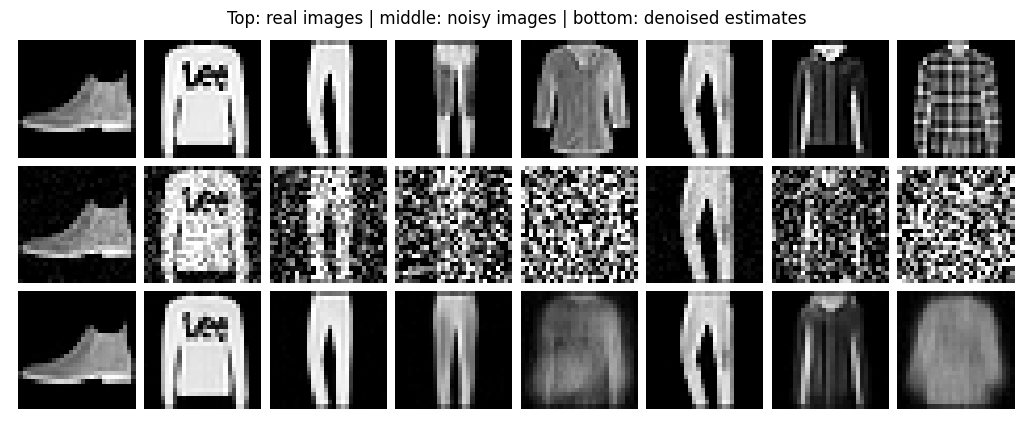

In [13]:
x0, _ = next(iter(test_loader))
x0 = x0[:8].to(device)
selected_steps = torch.tensor([10, 60, 120, 200, 280, 10, 120, 280], device=device)
xt = q_sample(x0, selected_steps)
x0_hat, score = estimate_x0_and_score(model, xt, selected_steps)

visual = torch.cat([
    0.5 * (x0 + 1.0),
    0.5 * (xt.clamp(-1, 1) + 1.0),
    0.5 * (x0_hat.clamp(-1, 1) + 1.0),
], dim=0)

plt.figure(figsize=(14, 5))
plt.imshow(utils.make_grid(visual.cpu(), nrow=8, pad_value=1.0).permute(1, 2, 0), cmap='gray')
plt.axis('off')
plt.title('Top: real images | middle: noisy images | bottom: denoised estimates')
plt.show()


### Three Samplers Driven by the Same Denoiser

The ancestral DDPM sampler, the reverse-time SDE solver, and the probability-flow ODE solver all start from Gaussian noise and query the same network. They differ only in how they convert the score information into a trajectory.

The main numerical subtlety is that the denoiser was trained with a **discrete variance schedule**. To interpret that schedule in continuous time, one should remember that the discrete coefficients behave like small increments of a continuous noise rate multiplied by a timestep. Equivalently, the continuous drift and diffusion must be scaled so that one solver step over a time interval of length roughly $1/T$ has the same magnitude as one DDPM step. With that scaling in place, the reverse-SDE and probability-flow updates become consistent with the pretrained DDPM denoiser rather than being far too weak to denoise meaningfully.

In [14]:
@torch.no_grad()
def sample_ddpm(model, n_samples=16, show_progress=True):
    model.eval()
    x = torch.randn(n_samples, channels, image_size, image_size, device=device)

    reverse_steps = reversed(range(timesteps))
    if show_progress:
        reverse_steps = tqdm(reverse_steps, total=timesteps, desc="ddpm sampling", leave=False)
    for t_scalar in reverse_steps:
        t = torch.full((n_samples,), t_scalar, device=device, dtype=torch.long)
        predicted_noise = model(x, t)
        beta_t = extract(betas, t, x.shape)
        sqrt_one_minus_alpha_t = extract(sqrt_one_minus_alphas, t, x.shape)
        sqrt_recip_bar_alpha_t = extract(sqrt_recip_bar_alphas, t, x.shape)
        model_mean = sqrt_recip_bar_alpha_t * (x - beta_t * predicted_noise / sqrt_one_minus_alpha_t)

        if t_scalar > 0:
            variance = extract(posterior_variance, t, x.shape)
            x = model_mean + torch.sqrt(variance) * torch.randn_like(x)
        else:
            x = model_mean

    x = x.clamp(-1, 1)
    return 0.5 * (x + 1.0)


@torch.no_grad()
def sample_reverse_sde(model, n_samples=16, num_steps=300, show_progress=True, x_init=None):
    model.eval()
    x = torch.randn(n_samples, channels, image_size, image_size, device=device) if x_init is None else x_init.clone().to(device)
    time_grid = torch.linspace(1.0, 1.0 / timesteps, num_steps, device=device)
    dt = 1.0 / num_steps

    iterator = time_grid
    if show_progress:
        iterator = tqdm(time_grid, total=num_steps, desc="reverse sde", leave=False)

    for tau in iterator:
        t_scalar = min(int(round(tau.item() * (timesteps - 1))), timesteps - 1)
        t = torch.full((n_samples,), t_scalar, device=device, dtype=torch.long)

        # Convert the discrete DDPM variance increment into a continuous-time rate.
        beta_cont = (timesteps * betas[t]).view(-1, 1, 1, 1)
        pred_noise = model(x, t)
        score = -pred_noise / extract(sqrt_one_minus_alphas, t, x.shape).clamp(min=1e-5)

        drift = -0.5 * beta_cont * x - beta_cont * score
        diffusion = torch.sqrt(beta_cont)
        x = x - drift * dt + diffusion * torch.sqrt(torch.tensor(dt, device=device)) * torch.randn_like(x)

    x = x.clamp(-1, 1)
    return 0.5 * (x + 1.0)


@torch.no_grad()
def sample_probability_flow_ode(model, n_samples=16, num_steps=300, show_progress=True, x_init=None):
    model.eval()
    x = torch.randn(n_samples, channels, image_size, image_size, device=device) if x_init is None else x_init.clone().to(device)
    time_grid = torch.linspace(1.0, 1.0 / timesteps, num_steps, device=device)
    dt = 1.0 / num_steps

    iterator = time_grid
    if show_progress:
        iterator = tqdm(time_grid, total=num_steps, desc="pf ode", leave=False)

    for tau in iterator:
        t_scalar = min(int(round(tau.item() * (timesteps - 1))), timesteps - 1)
        t = torch.full((n_samples,), t_scalar, device=device, dtype=torch.long)

        beta_cont = (timesteps * betas[t]).view(-1, 1, 1, 1)
        pred_noise = model(x, t)
        score = -pred_noise / extract(sqrt_one_minus_alphas, t, x.shape).clamp(min=1e-5)

        velocity = -0.5 * beta_cont * x - 0.5 * beta_cont * score
        x = x - velocity * dt

    x = x.clamp(-1, 1)
    return 0.5 * (x + 1.0)


### Visual Comparison of DDPM, Reverse SDE, and Probability-Flow ODE

Looking at the generated grids makes the distinction concrete. The ancestral DDPM and the reverse-time SDE both keep randomness in the trajectory. The probability-flow ODE produces a deterministic transport once the terminal Gaussian sample is fixed.

ddpm sampling:   0%|          | 0/300 [00:00<?, ?it/s]

reverse sde:   0%|          | 0/300 [00:00<?, ?it/s]

pf ode:   0%|          | 0/300 [00:00<?, ?it/s]

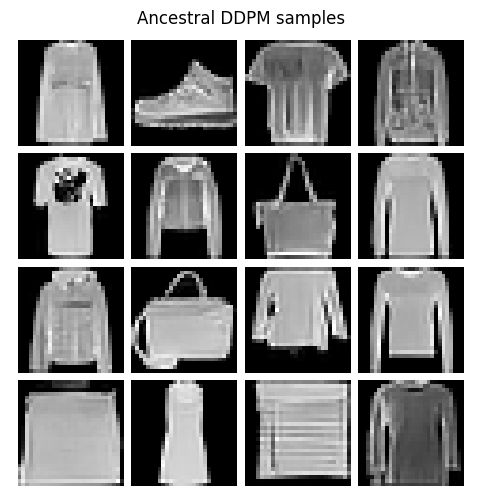

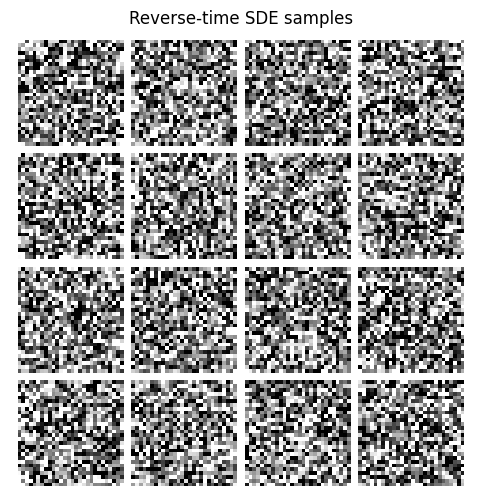

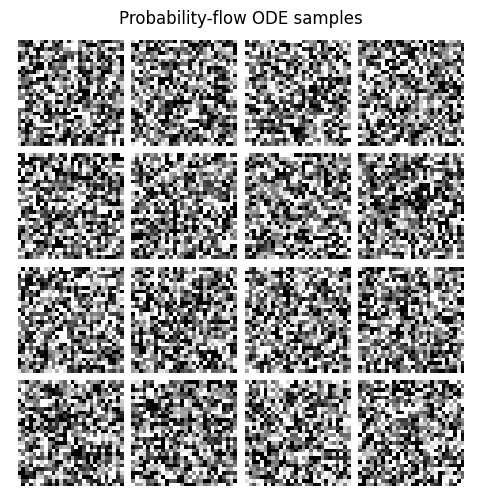

In [15]:
ddpm_samples = sample_ddpm(model, n_samples=16)
sde_samples = sample_reverse_sde(model, n_samples=16, num_steps=300)
pf_samples = sample_probability_flow_ode(model, n_samples=16, num_steps=300)

for title, samples in [
    ("Ancestral DDPM samples", ddpm_samples),
    ("Reverse-time SDE samples", sde_samples),
    ("Probability-flow ODE samples", pf_samples),
]:
    plt.figure(figsize=(6, 6))
    plt.imshow(utils.make_grid(samples.cpu(), nrow=4, pad_value=1.0).permute(1, 2, 0), cmap='gray')
    plt.axis('off')
    plt.title(title)
    plt.show()


### Fixing the Terminal Noise

A deterministic solver reveals itself most clearly when the starting noise is held fixed. Re-running the probability-flow ODE from the same terminal sample produces the same trajectory. Re-running the reverse-time SDE does not, because fresh Gaussian perturbations are injected during integration.

pf ode:   0%|          | 0/300 [00:00<?, ?it/s]

pf ode:   0%|          | 0/300 [00:00<?, ?it/s]

reverse sde:   0%|          | 0/300 [00:00<?, ?it/s]

reverse sde:   0%|          | 0/300 [00:00<?, ?it/s]

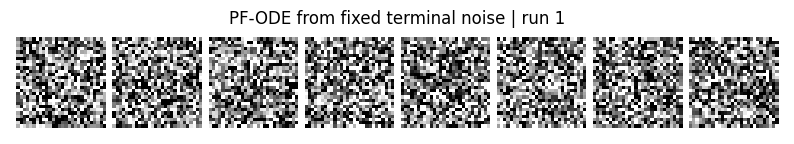

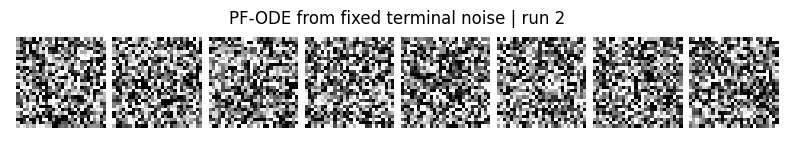

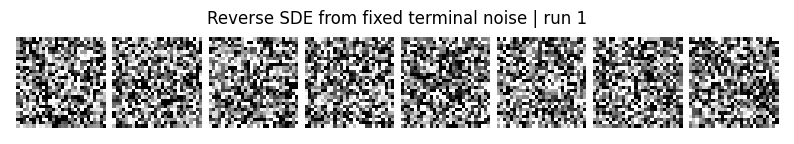

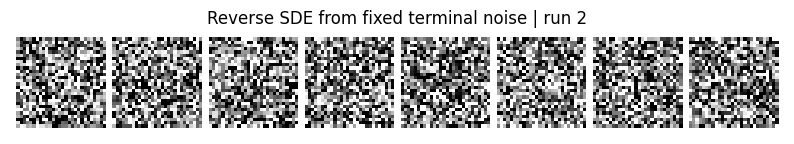

In [16]:
shared_noise = torch.randn(8, channels, image_size, image_size, device=device)

pf_first = sample_probability_flow_ode(model, n_samples=8, num_steps=300, x_init=shared_noise)
pf_second = sample_probability_flow_ode(model, n_samples=8, num_steps=300, x_init=shared_noise)

sde_first = sample_reverse_sde(model, n_samples=8, num_steps=300, x_init=shared_noise)
sde_second = sample_reverse_sde(model, n_samples=8, num_steps=300, x_init=shared_noise)

for title, samples in [
    ("PF-ODE from fixed terminal noise | run 1", pf_first),
    ("PF-ODE from fixed terminal noise | run 2", pf_second),
    ("Reverse SDE from fixed terminal noise | run 1", sde_first),
    ("Reverse SDE from fixed terminal noise | run 2", sde_second),
]:
    plt.figure(figsize=(10, 2.6))
    plt.imshow(utils.make_grid(samples.cpu(), nrow=8, pad_value=1.0).permute(1, 2, 0), cmap='gray')
    plt.axis('off')
    plt.title(title)
    plt.show()


### Batched FID and KID Across Samplers

Because the denoiser is fixed, the metric comparison is genuinely a comparison among samplers. The real-image statistics are accumulated once, while fake images are generated in small batches to keep memory usage controlled.

In [17]:
def prepare_for_metrics(images):
    if images.size(1) == 1:
        images = images.repeat(1, 3, 1, 1)
    return images.clamp(0.0, 1.0)


@torch.no_grad()
def compute_sampler_metrics(sample_fn, real_loader, num_fake=1000, metric_batch_size=64):
    fid = FrechetInceptionDistance(feature=2048, normalize=True, reset_real_features=False).to(device)
    kid = KernelInceptionDistance(subset_size=50, normalize=True, reset_real_features=False).to(device)

    real_seen = 0
    for real_images, _ in tqdm(real_loader, desc="real features", leave=False):
        real_images = real_images.to(device)
        if real_seen >= num_fake:
            break
        current = min(real_images.size(0), num_fake - real_seen)
        real_batch = prepare_for_metrics(0.5 * (real_images[:current] + 1.0))
        fid.update(real_batch, real=True)
        kid.update(real_batch, real=True)
        real_seen += current

    fake_seen = 0
    while fake_seen < num_fake:
        batch_n = min(metric_batch_size, num_fake - fake_seen)
        fake_images = sample_fn(batch_n).to(device)
        fake_batch = prepare_for_metrics(fake_images)
        fid.update(fake_batch, real=False)
        kid.update(fake_batch, real=False)
        fake_seen += batch_n

    kid_mean, kid_std = kid.compute()
    return {
        "fid": float(fid.compute().item()),
        "kid_mean": float(kid_mean.item()),
        "kid_std": float(kid_std.item()),
    }


In [18]:
sampler_metrics = {
    "ddpm": compute_sampler_metrics(lambda n: sample_ddpm(model, n_samples=n, show_progress=False), test_loader),
    "reverse_sde": compute_sampler_metrics(lambda n: sample_reverse_sde(model, n_samples=n, num_steps=300, show_progress=False), test_loader),
    "pf_ode": compute_sampler_metrics(lambda n: sample_probability_flow_ode(model, n_samples=n, num_steps=300, show_progress=False), test_loader),
}
sampler_metrics


c:\Users\tivog\deep-generative-models\.venv\lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


real features:   0%|          | 0/79 [00:00<?, ?it/s]

real features:   0%|          | 0/79 [00:00<?, ?it/s]

real features:   0%|          | 0/79 [00:00<?, ?it/s]

{'ddpm': {'fid': 52.791141510009766,
  'kid_mean': 0.02676919475197792,
  'kid_std': 0.00867660716176033},
 'reverse_sde': {'fid': 403.84161376953125,
  'kid_mean': 0.5648208856582642,
  'kid_std': 0.013782772235572338},
 'pf_ode': {'fid': 402.9354248046875,
  'kid_mean': 0.5610479712486267,
  'kid_std': 0.012373887933790684}}